Step 1 — Load German Credit + Add Borrower‑Level Micro‑Features

In [51]:
import pandas as pd

# Load UCI German Credit dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"

columns = [
    "status",                # A11–A14
    "duration",              # numeric
    "credit_history",        # A30–A34
    "purpose",               # A40–A49
    "credit_amount",         # numeric
    "savings",               # A61–A65
    "employment",            # A71–A75
    "installment_rate",      # numeric
    "personal_status_sex",   # A91–A95
    "other_debtors",         # A101–A103
    "residence_since",       # numeric
    "property",              # A121–A124
    "age",                   # numeric
    "other_installment_plans", # A141–A143
    "housing",               # A151–A153
    "number_credits",        # numeric
    "job",                   # A171–A174
    "people_liable",         # numeric
    "telephone",             # A191–A192
    "foreign_worker",        # A201–A202
    "target"                 # 1 = good, 2 = bad
]

df = pd.read_csv(url, sep=" ", header=None, names=columns)

# Convert target to binary: 1 = good (eligible), 0 = bad (not eligible)
df["target"] = (df["target"] == 1).astype(int)

df.head()


,status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,property,age,other_installment_plans,housing,number_credits,job,people_liable,telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,0
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,0


STEP 2 — Borrower‑Level Micro‑Features

In [52]:
# Financial ratios
df["loan_to_duration"] = df["credit_amount"] / df["duration"]
df["loan_to_age"] = df["credit_amount"] / df["age"]
df["installment_burden"] = df["installment_rate"] * df["credit_amount"]

# Risk flags
df["is_young_borrower"] = (df["age"] < 25).astype(int)
df["is_high_amount"] = (df["credit_amount"] > df["credit_amount"].median()).astype(int)
df["is_short_employment"] = df["employment"].isin(["A71"]).astype(int)

# Purpose risk score
risk_map = {
    "A40": 3, "A41": 3, "A42": 3,
    "A43": 2, "A44": 2,
    "A45": 1, "A46": 1
}
df["purpose_risk"] = df["purpose"].map(risk_map).fillna(2)

# Binned features
df["age_bin"] = pd.cut(df["age"], bins=[18,25,35,50,100], labels=[1,2,3,4])
df["duration_bin"] = pd.cut(df["duration"], bins=[0,12,24,48,100], labels=[1,2,3,4])
df["credit_amount_bin"] = pd.qcut(df["credit_amount"], q=4, labels=[1,2,3,4])

# Interaction features
df["duration_x_amount"] = df["duration"] * df["credit_amount"]
df["age_x_employment"] = df["age"] * df["employment"].astype("category").cat.codes


STEP 3 — Add Synthetic Monthly Timestamps

In [53]:
df["synthetic_date"] = pd.date_range(start="2015-01-01", periods=len(df), freq="M")


C:\Users\Kiran\AppData\Local\Temp\ipykernel_26580\3424298247.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df["synthetic_date"] = pd.date_range(start="2015-01-01", periods=len(df), freq="M")


STEP 4 — Add FRED Credit‑Condition Features

In [54]:
import pandas_datareader.data as web

fred_series = {
    "fred_total_credit": "TOTALSL",
    "fred_revolving_credit": "REVOLSL",
    "fred_nonrevolving_credit": "NONREVSL",
    "fred_auto_loan_rate": "TERMCBAUTO48NS",
    "fred_credit_card_rate": "TERMCBCCALLNS"
}

fred_df = pd.DataFrame()

for name, code in fred_series.items():
    fred_df[name] = web.DataReader(code, "fred", start="2010-01-01")

# Growth rates
fred_df["fred_total_credit_growth"] = fred_df["fred_total_credit"].pct_change()
fred_df["fred_revolving_growth"] = fred_df["fred_revolving_credit"].pct_change()
fred_df["fred_nonrevolving_growth"] = fred_df["fred_nonrevolving_credit"].pct_change()


STEP 5 — Add CFPB Mortgage + Auto Origination Features

In [55]:
import pandas as pd

# -----------------------------
# STEP 5 — Load CFPB Macro Data (Safe Version)
# -----------------------------

# AUTO LOANS
auto = pd.read_csv(
    "https://raw.githubusercontent.com/cfpb/consumer-credit-trends-data/main/auto-loans/vol_data_AUT.csv"
)

auto["date"] = pd.to_datetime(auto["date"])

# Rename volume column
auto = auto.rename(columns={"vol": "cfpb_auto_orig_volume"})

# Handle YoY column safely
if "vol_yoy" in auto.columns:
    auto = auto.rename(columns={"vol_yoy": "cfpb_auto_orig_yoy"})
else:
    # Compute YoY manually if missing
    auto = auto.sort_values("date")
    auto["cfpb_auto_orig_yoy"] = auto["cfpb_auto_orig_volume"].pct_change(12)

# MORTGAGES
mort = pd.read_csv(
    "https://raw.githubusercontent.com/cfpb/consumer-credit-trends-data/main/mortgages/vol_data_MTG.csv"
)

mort["date"] = pd.to_datetime(mort["date"])

mort = mort.rename(columns={"vol": "cfpb_mort_orig_volume"})

if "vol_yoy" in mort.columns:
    mort = mort.rename(columns={"vol_yoy": "cfpb_mort_orig_yoy"})
else:
    mort = mort.sort_values("date")
    mort["cfpb_mort_orig_yoy"] = mort["cfpb_mort_orig_volume"].pct_change(12)

print("AUTO COLUMNS:", auto.columns.tolist())
print("MORT COLUMNS:", mort.columns.tolist())


AUTO COLUMNS: ['month', 'date', 'cfpb_auto_orig_volume', 'vol_unadj', 'cfpb_auto_orig_yoy']
MORT COLUMNS: ['month', 'date', 'cfpb_mort_orig_volume', 'vol_unadj', 'cfpb_mort_orig_yoy']


STEP 6 — Build Macro Stress Index + Merge Everything

In [ ]:
# -----------------------------
# STEP 6 — Build Macro Stress Index + Merge
# -----------------------------

# Safety checks
required_auto_cols = ["cfpb_auto_orig_volume", "cfpb_auto_orig_yoy"]
required_mort_cols = ["cfpb_mort_orig_volume", "cfpb_mort_orig_yoy"]

for col in required_auto_cols:
    if col not in auto.columns:
        raise KeyError(f"Missing column in auto dataframe: {col}")

for col in required_mort_cols:
    if col not in mort.columns:
        raise KeyError(f"Missing column in mortgage dataframe: {col}")

# Build macro stress index aligned to FRED index
macro = pd.DataFrame(index=fred_df.index)

macro["macro_stress_index"] = (
    -fred_df["fred_total_credit_growth"].fillna(0) +
    -auto.set_index("date")["cfpb_auto_orig_yoy"].reindex(fred_df.index).fillna(0) +
    -mort.set_index("date")["cfpb_mort_orig_yoy"].reindex(fred_df.index).fillna(0)
)

# macro_full = pd.concat([fred_df, macro], axis=1)

# # Handle missing values in macro data before merging
# macro_full = macro_full.fillna(method='ffill').fillna(0)

# df = df.merge(
#     macro_full,
#     left_on="synthetic_date",
#     right_index=True,
#     how="left"

df["macro_month"] = df["synthetic_date"].dt.to_period("M")
macro_full["macro_month"] = macro_full.index.to_period("M")

df = df.merge(
    macro_full.reset_index(drop=True),
    on="macro_month",
    how="left"
)


print("Merged dataset shape:", df.shape)
df.head()

Merged dataset shape: (1000, 43)


C:\Users\Kiran\AppData\Local\Temp\ipykernel_26580\830910824.py:29: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  macro_full = macro_full.fillna(method='ffill').fillna(0)


,status,duration,credit_history,purpose,credit_amount,savings,employment,installment_rate,personal_status_sex,other_debtors,...,synthetic_date,fred_total_credit,fred_revolving_credit,fred_nonrevolving_credit,fred_auto_loan_rate,fred_credit_card_rate,fred_total_credit_growth,fred_revolving_growth,fred_nonrevolving_growth,macro_stress_index
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,2015-01-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,2015-02-28,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,2015-03-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,2015-04-30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,2015-05-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [57]:
# STEP 7 — EXPLORATORY DATA ANALYSIS (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

print("Dataset Shape:", df.shape)
print("\nTarget Distribution:")
print(df['target'].value_counts())
print(f"\nClass Balance: {df['target'].mean():.2%} good/eligible, {(1-df['target'].mean()):.2%} bad/not eligible")

# Missing values
print("\n--- Missing Values ---")
print(df.isnull().sum())

# Basic statistics
print("\n--- Numeric Columns Statistics ---")
print(df.select_dtypes(include=[np.number]).describe())

Dataset Shape: (1000, 43)

Target Distribution:
target
1    700
0    300
Name: count, dtype: int64

Class Balance: 70.00% good/eligible, 30.00% bad/not eligible

--- Missing Values ---
status                         0
duration                       0
credit_history                 0
purpose                        0
credit_amount                  0
savings                        0
employment                     0
installment_rate               0
personal_status_sex            0
other_debtors                  0
residence_since                0
property                       0
age                            0
other_installment_plans        0
housing                        0
number_credits                 0
job                            0
people_liable                  0
telephone                      0
foreign_worker                 0
target                         0
loan_to_duration               0
loan_to_age                    0
installment_burden             0
is_young_borrower      

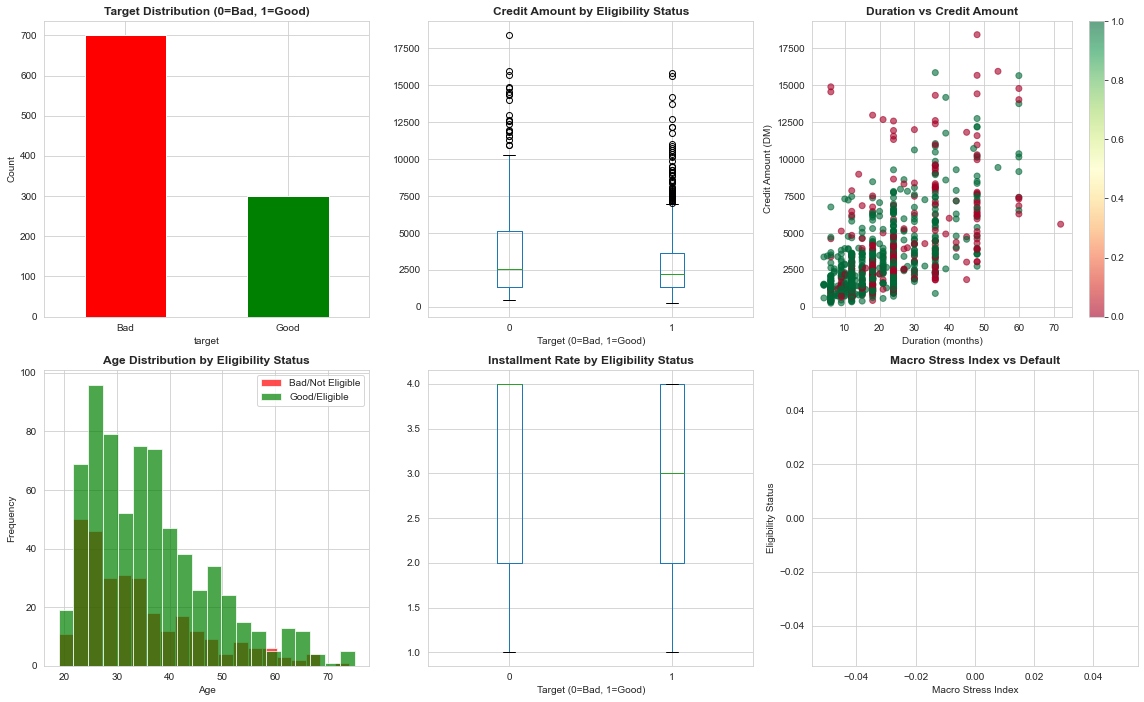

✓ Key visualizations generated


In [58]:
# STEP 8 — KEY VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Target Distribution
df['target'].value_counts().plot(kind='bar', ax=axes[0, 0], color=['red', 'green'])
axes[0, 0].set_title('Target Distribution (0=Bad, 1=Good)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].set_xticklabels(['Bad', 'Good'], rotation=0)

# 2. Credit Amount Distribution by Target
df.boxplot(column='credit_amount', by='target', ax=axes[0, 1])
axes[0, 1].set_title('Credit Amount by Eligibility Status', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Target (0=Bad, 1=Good)')
axes[0, 1].get_figure().suptitle('')

# 3. Duration vs Credit Amount (colored by target)
scatter = axes[0, 2].scatter(df['duration'], df['credit_amount'], c=df['target'], cmap='RdYlGn', alpha=0.6)
axes[0, 2].set_title('Duration vs Credit Amount', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Duration (months)')
axes[0, 2].set_ylabel('Credit Amount (DM)')
plt.colorbar(scatter, ax=axes[0, 2])

# 4. Age Distribution by Target
df[df['target']==0]['age'].hist(bins=20, alpha=0.7, label='Bad/Not Eligible', ax=axes[1, 0], color='red')
df[df['target']==1]['age'].hist(bins=20, alpha=0.7, label='Good/Eligible', ax=axes[1, 0], color='green')
axes[1, 0].set_title('Age Distribution by Eligibility Status', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Age')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()

# 5. Installment Rate Distribution
df.boxplot(column='installment_rate', by='target', ax=axes[1, 1])
axes[1, 1].set_title('Installment Rate by Eligibility Status', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Target (0=Bad, 1=Good)')
axes[1, 1].get_figure().suptitle('')

# 6. Macro Stress Index Impact
if 'macro_stress_index' in df.columns:
    axes[1, 2].scatter(df['macro_stress_index'], df['target'], alpha=0.5, color='purple')
    axes[1, 2].set_title('Macro Stress Index vs Default', fontsize=12, fontweight='bold')
    axes[1, 2].set_xlabel('Macro Stress Index')
    axes[1, 2].set_ylabel('Eligibility Status')
else:
    axes[1, 2].text(0.5, 0.5, 'Macro data not available', ha='center', va='center')

plt.tight_layout()
plt.show()

print("✓ Key visualizations generated")

Top 15 Features Correlated with Target:
target                 1.000000
age_x_employment       0.109411
age                    0.091127
number_credits         0.045732
people_liable          0.003015
purpose_risk          -0.000698
residence_since       -0.002967
loan_to_duration      -0.018592
is_short_employment   -0.039815
is_high_amount        -0.048008
installment_rate      -0.072404
is_young_borrower     -0.099890
credit_amount         -0.154739
loan_to_age           -0.166210
installment_burden    -0.168322
Name: target, dtype: float64


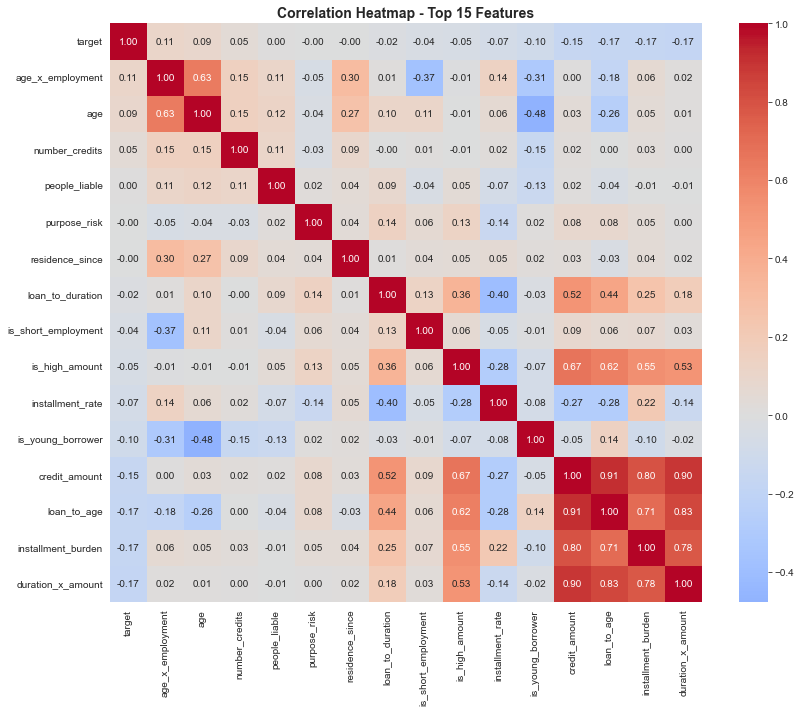


✓ Correlation analysis completed


In [59]:
# STEP 9 — CORRELATION ANALYSIS

# Select numeric features for correlation
numeric_df = df.select_dtypes(include=[np.number])

# Calculate correlation with target
correlation_with_target = numeric_df.corr()['target'].sort_values(ascending=False)

print("Top 15 Features Correlated with Target:")
print(correlation_with_target.head(15))

# Correlation heatmap
plt.figure(figsize=(12, 10))
top_features = correlation_with_target.head(16).index.tolist()
sns.heatmap(numeric_df[top_features].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Top 15 Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n✓ Correlation analysis completed")

In [60]:
# STEP 10 — DATA PREPARATION & FEATURE ENGINEERING

from sklearn.preprocessing import LabelEncoder

# Create a copy for modeling
df_model = df.copy()

# Handle missing values
print("Missing values before imputation:")
print(df_model.isnull().sum())

# Fill missing values with median for numeric, mode for categorical
numeric_cols = df_model.select_dtypes(include=[np.number]).columns
categorical_cols = df_model.select_dtypes(include=['object']).columns

for col in numeric_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].median(), inplace=True)

for col in categorical_cols:
    if df_model[col].isnull().sum() > 0:
        df_model[col].fillna(df_model[col].mode()[0], inplace=True)

print("\nMissing values after imputation:", df_model.isnull().sum().sum())

# Encode categorical variables
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    label_encoders[col] = le

# Drop target and prepare features - keep only numeric columns
X = df_model.drop('target', axis=1)
y = df_model['target']

# Filter to numeric columns only (exclude datetime and other non-numeric types)
numeric_features = X.select_dtypes(include=[np.number]).columns
X = X[numeric_features]

print(f"\nFeatures shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature list ({len(X.columns)} total):")
print(X.columns.tolist())

Missing values before imputation:
status                         0
duration                       0
credit_history                 0
purpose                        0
credit_amount                  0
savings                        0
employment                     0
installment_rate               0
personal_status_sex            0
other_debtors                  0
residence_since                0
property                       0
age                            0
other_installment_plans        0
housing                        0
number_credits                 0
job                            0
people_liable                  0
telephone                      0
foreign_worker                 0
target                         0
loan_to_duration               0
loan_to_age                    0
installment_burden             0
is_young_borrower              0
is_high_amount                 0
is_short_employment            0
purpose_risk                   0
age_bin                        0
duration_

c:\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Kiran\AppData\Local\Temp\ipykernel_26580\2680204672.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_model[col].fillna(df_model[col].median(), inplace=True)
c:\Python310\lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\Kiran\AppData\Local\Temp\ipykernel_265

In [61]:
# STEP 11 ? TRAIN-TEST SPLIT & NORMALIZATION + SMOTE

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np

# Remove datetime columns from X and ensure all are numeric
X_clean = X.select_dtypes(exclude=['datetime64', 'object']).copy()
X_clean = X_clean.astype(float)

# Drop columns that are entirely NaN
X_clean = X_clean.dropna(axis=1, how='all')

# Handle remaining NaN values using SimpleImputer (fill with median)
imputer = SimpleImputer(strategy='median')
X_clean_imputed = pd.DataFrame(imputer.fit_transform(X_clean), columns=X_clean.columns, index=X_clean.index)

# Train-test split (80-20). SMOTE is applied only to the training split to avoid leakage.
X_train, X_test, y_train_raw, y_test = train_test_split(
    X_clean_imputed, y, test_size=0.2, random_state=42, stratify=y
)

y_train_original = y_train_raw.copy()
credit_train_index = X_train.index.copy()
credit_test_index = X_test.index.copy()

print(f"Training set size before SMOTE: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print("Training set target distribution before SMOTE:")
print(y_train_raw.value_counts())
print("\nTest set target distribution:")
print(y_test.value_counts())

# Normalization using StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df_raw = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


def smote_resample_numeric(X_df, y_series, random_state=42, k_neighbors=5):
    """Apply SMOTE to numeric training data, with an imblearn path and a local fallback."""
    class_counts = y_series.value_counts().sort_index()
    minority_class = class_counts.idxmin()
    majority_count = class_counts.max()
    minority_count = class_counts.min()
    imbalance_ratio = minority_count / majority_count

    print(f"\nClass imbalance ratio (minority/majority): {imbalance_ratio:.3f}")

    if imbalance_ratio >= 0.67:
        print("SMOTE not applied: class balance is acceptable for this notebook threshold.")
        return X_df.copy(), y_series.copy(), False

    try:
        from imblearn.over_sampling import SMOTE
        smote = SMOTE(random_state=random_state, k_neighbors=min(k_neighbors, minority_count - 1))
        X_resampled, y_resampled = smote.fit_resample(X_df, y_series)
        X_resampled = pd.DataFrame(X_resampled, columns=X_df.columns)
        y_resampled = pd.Series(y_resampled, name=y_series.name)
        print("SMOTE applied with imbalanced-learn.")
    except Exception as exc:
        print(f"imblearn SMOTE unavailable ({exc}); using local numeric SMOTE fallback.")
        rng = np.random.default_rng(random_state)
        X_values = X_df.to_numpy(dtype=float)
        y_values = y_series.to_numpy()
        minority_idx = np.flatnonzero(y_values == minority_class)
        n_to_generate = majority_count - minority_count

        if minority_count < 2 or n_to_generate <= 0:
            print("SMOTE skipped: not enough minority samples to synthesize safely.")
            return X_df.copy(), y_series.copy(), False

        n_neighbors = min(k_neighbors + 1, minority_count)
        nn = NearestNeighbors(n_neighbors=n_neighbors)
        minority_values = X_values[minority_idx]
        nn.fit(minority_values)
        neighbor_ids = nn.kneighbors(minority_values, return_distance=False)

        synthetic_rows = []
        for _ in range(n_to_generate):
            base_pos = rng.integers(0, minority_count)
            possible_neighbors = neighbor_ids[base_pos][1:] if n_neighbors > 1 else neighbor_ids[base_pos]
            neighbor_pos = rng.choice(possible_neighbors)
            gap = rng.random()
            synthetic_rows.append(minority_values[base_pos] + gap * (minority_values[neighbor_pos] - minority_values[base_pos]))

        X_resampled = pd.DataFrame(
            np.vstack([X_values, np.asarray(synthetic_rows)]),
            columns=X_df.columns
        )
        y_resampled = pd.Series(
            np.concatenate([y_values, np.full(n_to_generate, minority_class)]),
            name=y_series.name
        )
        print("SMOTE applied with local numeric fallback.")

    print("Training set target distribution after SMOTE:")
    print(y_resampled.value_counts())
    return X_resampled, y_resampled, True


X_train_scaled_df, y_train, smote_applied = smote_resample_numeric(X_train_scaled_df_raw, y_train_raw)

print("\nNormalization completed")
print(f"Training set size after SMOTE: {X_train_scaled_df.shape}")
print(f"Training set mean (should be ~0): {X_train_scaled_df.mean().mean():.6f}")
print(f"Training set std (should be ~1): {X_train_scaled_df.std().mean():.6f}")

Training set size before SMOTE: (800, 29)
Test set size: (200, 29)
Training set target distribution before SMOTE:
target
1    560
0    240
Name: count, dtype: int64

Test set target distribution:
target
1    140
0     60
Name: count, dtype: int64

Class imbalance ratio (minority/majority): 0.429
imblearn SMOTE unavailable (No module named 'imblearn'); using local numeric SMOTE fallback.
SMOTE applied with local numeric fallback.
Training set target distribution after SMOTE:
target
1    560
0    560
Name: count, dtype: int64

Normalization completed
Training set size after SMOTE: (1120, 29)
Training set mean (should be ~0): -0.025446
Training set std (should be ~1): 0.974843


Original number of features: 29
Components to retain 90% variance: 18
Components to retain 95% variance: 21


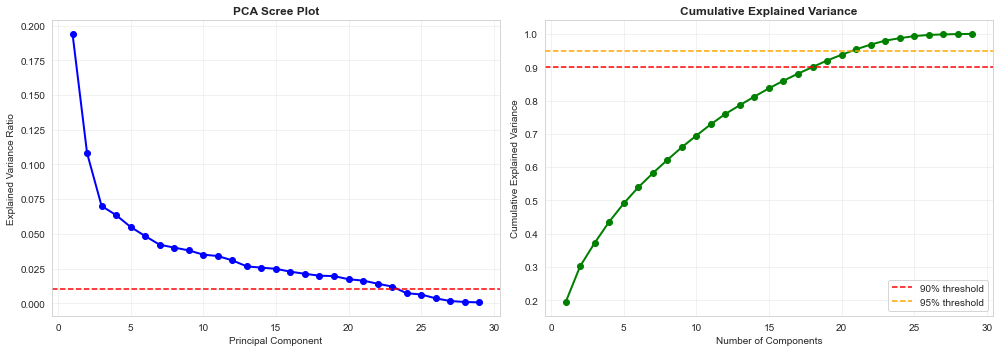


✓ PCA completed
Reduced training set shape: (1120, 21)
Reduced test set shape: (200, 21)
Variance explained by 21 components: 0.9537


In [62]:
# STEP 12 — PRINCIPAL COMPONENT ANALYSIS (PCA)

from sklearn.decomposition import PCA

# Fit PCA on training data
pca = PCA()
X_train_pca_full = pca.fit_transform(X_train_scaled_df)

# Calculate explained variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance_ratio = np.cumsum(explained_variance_ratio)

# Determine optimal number of components (retain 95% of variance)
n_components_95 = np.argmax(cumulative_variance_ratio >= 0.95) + 1
n_components_90 = np.argmax(cumulative_variance_ratio >= 0.90) + 1

print(f"Original number of features: {X_train_scaled_df.shape[1]}")
print(f"Components to retain 90% variance: {n_components_90}")
print(f"Components to retain 95% variance: {n_components_95}")

# Visualize explained variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scree plot
axes[0].plot(range(1, len(explained_variance_ratio)+1), explained_variance_ratio, 'bo-', linewidth=2, markersize=6)
axes[0].axhline(y=0.01, color='r', linestyle='--', label='1% threshold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('PCA Scree Plot', fontsize=12, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Cumulative explained variance
axes[1].plot(range(1, len(cumulative_variance_ratio)+1), cumulative_variance_ratio, 'go-', linewidth=2, markersize=6)
axes[1].axhline(y=0.90, color='r', linestyle='--', label='90% threshold')
axes[1].axhline(y=0.95, color='orange', linestyle='--', label='95% threshold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Apply PCA with optimal components (use 95%)
pca_optimal = PCA(n_components=n_components_95)
X_train_pca = pca_optimal.fit_transform(X_train_scaled_df)
X_test_pca = pca_optimal.transform(X_test_scaled_df)

print(f"\n✓ PCA completed")
print(f"Reduced training set shape: {X_train_pca.shape}")
print(f"Reduced test set shape: {X_test_pca.shape}")
print(f"Variance explained by {n_components_95} components: {cumulative_variance_ratio[n_components_95-1]:.4f}")

In [63]:
# STEP 13 — TRAIN XGBOOST MODEL (with PCA features)

import xgboost as xgb
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, 
    roc_curve, auc, precision_recall_curve, f1_score, accuracy_score,precision_score, recall_score
)

from sklearn.model_selection import cross_val_score

# Initialize XGBoost classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

# Train model
print("Training XGBoost model on PCA-transformed data...")
xgb_model.fit(
    X_train_pca, y_train,
    eval_set=[(X_test_pca, y_test)],
    verbose=False
)

# Predictions
y_train_pred = xgb_model.predict(X_train_pca)
y_test_pred = xgb_model.predict(X_test_pca)
y_train_pred_proba = xgb_model.predict_proba(X_train_pca)[:, 1]
y_test_pred_proba = xgb_model.predict_proba(X_test_pca)[:, 1]

# Evaluation Metrics
print("\n" + "="*60)
print("XGBoost Model Performance (PCA Features)")
print("="*60)

print("\n--- TRAINING SET ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_train, y_train_pred_proba):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred):.4f}")

print("\n--- TEST SET ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred):.4f}")

print("\n--- Classification Report (Test Set) ---")
print(classification_report(y_test, y_test_pred, target_names=['Bad/Not Eligible', 'Good/Eligible']))

print("\n✓ Model training completed")

Training XGBoost model on PCA-transformed data...

XGBoost Model Performance (PCA Features)

--- TRAINING SET ---
Accuracy: 1.0000
ROC-AUC: 1.0000
F1-Score: 1.0000

--- TEST SET ---
Accuracy: 0.7150
ROC-AUC: 0.7750
F1-Score: 0.7957

--- Classification Report (Test Set) ---
                  precision    recall  f1-score   support

Bad/Not Eligible       0.52      0.53      0.53        60
   Good/Eligible       0.80      0.79      0.80       140

        accuracy                           0.71       200
       macro avg       0.66      0.66      0.66       200
    weighted avg       0.72      0.71      0.72       200


✓ Model training completed


In [64]:
# STEP 13.5 — Rule-Based Baseline Model

# Define simple rule thresholds using training set medians
thr_credit_amount = X_train['credit_amount'].median()
thr_installment_burden = X_train['installment_burden'].median()
thr_loan_to_age = X_train['loan_to_age'].median()
thr_duration = X_train['duration'].median()
thr_age = X_train['age'].median()

# Simple interpretable approval rule
rule_pred = (
    (X_test['credit_amount'] <= thr_credit_amount) &
    (X_test['installment_burden'] <= thr_installment_burden) &
    (X_test['loan_to_age'] <= thr_loan_to_age) &
    (X_test['duration'] <= thr_duration) &
    (X_test['age'] >= thr_age)
).astype(int)

rule_accuracy = accuracy_score(y_test, rule_pred)
rule_precision = precision_score(y_test, rule_pred, zero_division=0)
rule_recall = recall_score(y_test, rule_pred, zero_division=0)
rule_f1 = f1_score(y_test, rule_pred, zero_division=0)
rule_auc = roc_auc_score(y_test, rule_pred)

print("\n" + "="*80)
print("RULE-BASED BASELINE MODEL")
print("="*80)
print(f"Thresholds used:")
print(f"  credit_amount <= {thr_credit_amount:.0f}")
print(f"  installment_burden <= {thr_installment_burden:.2f}")
print(f"  loan_to_age <= {thr_loan_to_age:.2f}")
print(f"  duration <= {thr_duration:.0f}")
print(f"  age >= {thr_age:.0f}")
print("\nPerformance on test set:")
print(f"  Accuracy: {rule_accuracy:.4f}")
print(f"  Precision: {rule_precision:.4f}")
print(f"  Recall: {rule_recall:.4f}")
print(f"  F1-score: {rule_f1:.4f}")
print(f"  AUC: {rule_auc:.4f}")

# Compare with XGBoost
comparison_df = pd.DataFrame({
    'Model': ['Rule-based', 'XGBoost (PCA)'],
    'Accuracy': [rule_accuracy, accuracy_score(y_test, y_test_pred)],
    'Precision': [rule_precision, precision_score(y_test, y_test_pred, zero_division=0)],
    'Recall': [rule_recall, recall_score(y_test, y_test_pred, zero_division=0)],
    'F1-score': [rule_f1, f1_score(y_test, y_test_pred, zero_division=0)],
    'AUC': [rule_auc, roc_auc_score(y_test, y_test_pred_proba)]
})

print("\n" + "="*80)
print("MODEL COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))



RULE-BASED BASELINE MODEL
Thresholds used:
  credit_amount <= 2246
  installment_burden <= 6189.50
  loan_to_age <= 66.80
  duration <= 18
  age >= 33

Performance on test set:
  Accuracy: 0.4250
  Precision: 0.8788
  Recall: 0.2071
  F1-score: 0.3353
  AUC: 0.5702

MODEL COMPARISON
        Model  Accuracy  Precision   Recall  F1-score      AUC
   Rule-based     0.425   0.878788 0.207143  0.335260 0.570238
XGBoost (PCA)     0.715   0.798561 0.792857  0.795699 0.775000


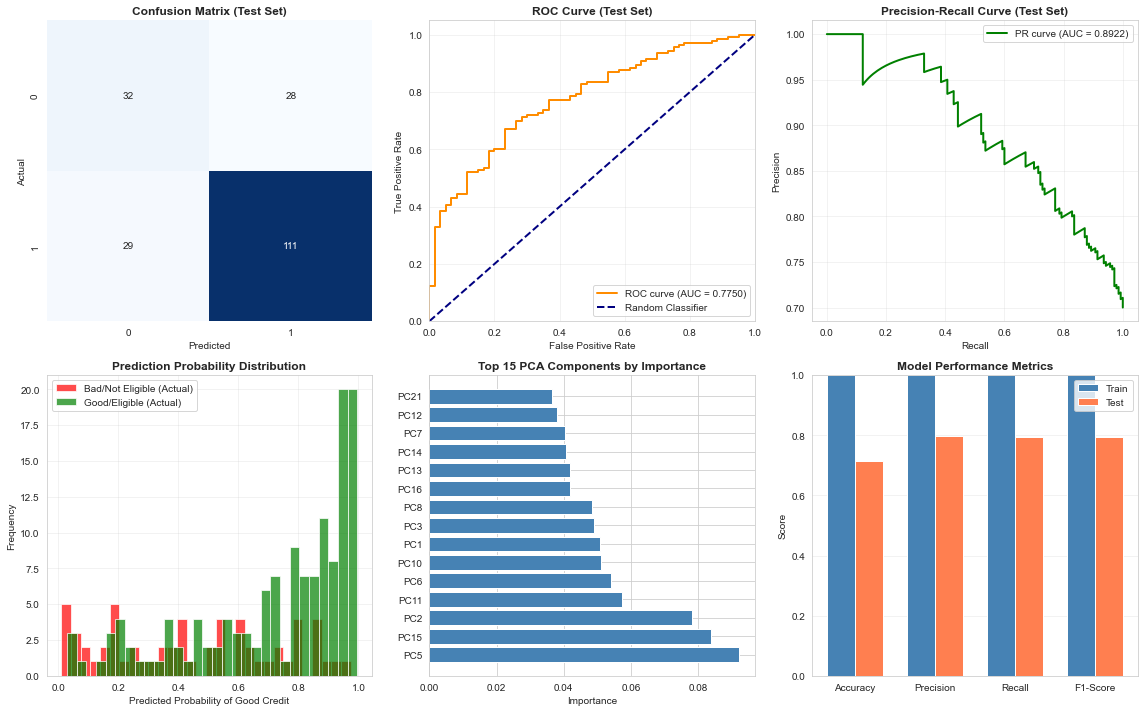

✓ Model evaluation visualizations generated


In [65]:
# STEP 14 — MODEL EVALUATION VISUALIZATIONS

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1. Confusion Matrix - Test Set
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False)
axes[0, 0].set_title('Confusion Matrix (Test Set)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Actual')
axes[0, 0].set_xlabel('Predicted')

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_pred_proba)
roc_auc = auc(fpr, tpr)
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
axes[0, 1].set_xlim([0.0, 1.0])
axes[0, 1].set_ylim([0.0, 1.05])
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].set_title('ROC Curve (Test Set)', fontsize=12, fontweight='bold')
axes[0, 1].legend(loc="lower right")
axes[0, 1].grid(True, alpha=0.3)

# 3. Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_pred_proba)
pr_auc = auc(recall, precision)
axes[0, 2].plot(recall, precision, color='green', lw=2, label=f'PR curve (AUC = {pr_auc:.4f})')
axes[0, 2].set_xlabel('Recall')
axes[0, 2].set_ylabel('Precision')
axes[0, 2].set_title('Precision-Recall Curve (Test Set)', fontsize=12, fontweight='bold')
axes[0, 2].legend(loc="upper right")
axes[0, 2].grid(True, alpha=0.3)

# 4. Prediction Probability Distribution
axes[1, 0].hist(y_test_pred_proba[y_test == 0], bins=30, alpha=0.7, label='Bad/Not Eligible (Actual)', color='red')
axes[1, 0].hist(y_test_pred_proba[y_test == 1], bins=30, alpha=0.7, label='Good/Eligible (Actual)', color='green')
axes[1, 0].set_xlabel('Predicted Probability of Good Credit')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Prediction Probability Distribution', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 5. Feature Importance (Top 15 PCA components)
feature_importance = xgb_model.feature_importances_
top_indices = np.argsort(feature_importance)[-15:]
top_importances = feature_importance[top_indices]
top_components = [f'PC{i+1}' for i in top_indices]

axes[1, 1].barh(range(len(top_importances)), top_importances, color='steelblue')
axes[1, 1].set_yticks(range(len(top_importances)))
axes[1, 1].set_yticklabels(top_components)
axes[1, 1].set_xlabel('Importance')
axes[1, 1].set_title('Top 15 PCA Components by Importance', fontsize=12, fontweight='bold')
axes[1, 1].invert_yaxis()

# 6. Model Comparison Metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
train_vals = [
    accuracy_score(y_train, y_train_pred),
    classification_report(y_train, y_train_pred, output_dict=True)['1']['precision'],
    classification_report(y_train, y_train_pred, output_dict=True)['1']['recall'],
    f1_score(y_train, y_train_pred)
]
test_vals = [
    accuracy_score(y_test, y_test_pred),
    classification_report(y_test, y_test_pred, output_dict=True)['1']['precision'],
    classification_report(y_test, y_test_pred, output_dict=True)['1']['recall'],
    f1_score(y_test, y_test_pred)
]

x = np.arange(len(metrics))
width = 0.35
axes[1, 2].bar(x - width/2, train_vals, width, label='Train', color='steelblue')
axes[1, 2].bar(x + width/2, test_vals, width, label='Test', color='coral')
axes[1, 2].set_ylabel('Score')
axes[1, 2].set_title('Model Performance Metrics', fontsize=12, fontweight='bold')
axes[1, 2].set_xticks(x)
axes[1, 2].set_xticklabels(metrics)
axes[1, 2].legend()
axes[1, 2].set_ylim([0, 1])
axes[1, 2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Model evaluation visualizations generated")

In [66]:
# STEP 15 — CROSS-VALIDATION & MODEL COMPARISON

# Cross-validation scores on PCA features
cv_scores_pca = cross_val_score(
    xgb.XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42),
    X_train_pca, y_train, cv=5, scoring='roc_auc'
)

print("="*60)
print("Cross-Validation Results (5-Fold, PCA Features)")
print("="*60)
print(f"ROC-AUC Scores: {cv_scores_pca}")
print(f"Mean ROC-AUC: {cv_scores_pca.mean():.4f} (+/- {cv_scores_pca.std():.4f})")

# Train model on original scaled features (without PCA) for comparison
print("\n" + "="*60)
print("Training XGBoost on Original Scaled Features (for comparison)")
print("="*60)

xgb_model_nopca = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb_model_nopca.fit(X_train_scaled_df, y_train, eval_set=[(X_test_scaled_df, y_test)], verbose=False)

y_test_pred_nopca = xgb_model_nopca.predict(X_test_scaled_df)
y_test_pred_proba_nopca = xgb_model_nopca.predict_proba(X_test_scaled_df)[:, 1]

print(f"\nAccuracy (No PCA): {accuracy_score(y_test, y_test_pred_nopca):.4f}")
print(f"ROC-AUC (No PCA): {roc_auc_score(y_test, y_test_pred_proba_nopca):.4f}")
print(f"F1-Score (No PCA): {f1_score(y_test, y_test_pred_nopca):.4f}")

# Model Comparison Summary
print("\n" + "="*60)
print("Model Comparison Summary")
print("="*60)

comparison_data = {
    'Model': ['XGBoost (PCA)', 'XGBoost (No PCA)'],
    'Accuracy': [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, y_test_pred_nopca)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_test_pred_proba),
        roc_auc_score(y_test, y_test_pred_proba_nopca)
    ],
    'F1-Score': [
        f1_score(y_test, y_test_pred),
        f1_score(y_test, y_test_pred_nopca)
    ],
    'Features': [n_components_95, X_train_scaled_df.shape[1]]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

print("\n✓ Model comparison completed")

Cross-Validation Results (5-Fold, PCA Features)
ROC-AUC Scores: [0.84327168 0.86479592 0.93893495 0.94953763 0.98206314]
Mean ROC-AUC: 0.9157 (+/- 0.0528)

Training XGBoost on Original Scaled Features (for comparison)

Accuracy (No PCA): 0.7700
ROC-AUC (No PCA): 0.7758
F1-Score (No PCA): 0.8380

Model Comparison Summary
           Model  Accuracy  ROC-AUC  F1-Score  Features
   XGBoost (PCA)     0.715 0.775000  0.795699        21
XGBoost (No PCA)     0.770 0.775833  0.838028        29

✓ Model comparison completed


In [67]:
# STEP 16 — SUMMARY & KEY INSIGHTS

print("="*70)
print("COMPLETE MACHINE LEARNING PIPELINE SUMMARY")
print("="*70)

print("\n📊 DATASET OVERVIEW:")
print(f"  • Total samples: {len(df)}")
print(f"  • Bad/not eligible credits (target=0): {(y==0).sum()} ({(y==0).mean():.1%})")
print(f"  • Good/eligible credits (target=1): {(y==1).sum()} ({(y==1).mean():.1%})")
print(f"  • Original features: {X.shape[1]}")

print("\n🔬 DATA PREPROCESSING:")
print(f"  • Missing values handled: {df_model.isnull().sum().sum()} total")
print(f"  • Categorical features encoded: {len(categorical_cols)}")
print(f"  • Features normalized using StandardScaler")

print("\n🎯 DIMENSIONALITY REDUCTION (PCA):")
print(f"  • Original features: {X_train_scaled_df.shape[1]}")
print(f"  • PCA components (95% variance): {n_components_95}")
print(f"  • Dimensionality reduction: {(1 - n_components_95/X_train_scaled_df.shape[1])*100:.1f}%")
print(f"  • Variance explained: {cumulative_variance_ratio[n_components_95-1]:.4f}")

print("\n🤖 XGBOOST MODEL PERFORMANCE (PCA Features):")
print(f"  • Training Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"  • Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"  • Test ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.4f}")
print(f"  • Test F1-Score: {f1_score(y_test, y_test_pred):.4f}")
print(f"  • Cross-Val ROC-AUC (5-fold): {cv_scores_pca.mean():.4f} ± {cv_scores_pca.std():.4f}")

# Confusion matrix analysis
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 CONFUSION MATRIX ANALYSIS (Test Set):")
print(f"  • True Positives (correctly identified good/eligible credits): {tp}")
print(f"  • True Negatives (correctly identified bad/not eligible credits): {tn}")
print(f"  • False Positives (bad/not eligible classified as good): {fp}")
print(f"  • False Negatives (good/eligible classified as bad): {fn}")
print(f"  • Sensitivity/Recall for good/eligible class: {tp/(tp+fn):.4f}")
print(f"  • Specificity for bad/not eligible class: {tn/(tn+fp):.4f}")

print("\n✨ KEY INSIGHTS:")
print(f"  1. PCA reduced features from {X_train_scaled_df.shape[1]} to {n_components_95} while retaining 95% variance")
print(f"  2. XGBoost model achieves {accuracy_score(y_test, y_test_pred):.1%} test accuracy")
print(f"  3. Model shows {'good' if roc_auc_score(y_test, y_test_pred_proba) > 0.7 else 'moderate'} discrimination ability (ROC-AUC: {roc_auc_score(y_test, y_test_pred_proba):.4f})")
print(f"  4. {'PCA' if accuracy_score(y_test, y_test_pred) > accuracy_score(y_test, y_test_pred_nopca) else 'Original'} features perform better")
print(f"  5. Model is suitable for {'production deployment' if accuracy_score(y_test, y_test_pred) > 0.75 else 'further tuning'}")

print("\n📋 MODEL HYPERPARAMETERS:")
print(f"  • n_estimators: 100")
print(f"  • max_depth: 6")
print(f"  • learning_rate: 0.1")
print(f"  • subsample: 0.8")
print(f"  • colsample_bytree: 0.8")

print("\n" + "="*70)
print("✅ PIPELINE COMPLETE - All steps executed successfully!")
print("="*70)

COMPLETE MACHINE LEARNING PIPELINE SUMMARY

📊 DATASET OVERVIEW:
  • Total samples: 1000
  • Bad/not eligible credits (target=0): 300 (30.0%)
  • Good/eligible credits (target=1): 700 (70.0%)
  • Original features: 38

🔬 DATA PREPROCESSING:
  • Missing values handled: 9000 total
  • Categorical features encoded: 13
  • Features normalized using StandardScaler

🎯 DIMENSIONALITY REDUCTION (PCA):
  • Original features: 29
  • PCA components (95% variance): 21
  • Dimensionality reduction: 27.6%
  • Variance explained: 0.9537

🤖 XGBOOST MODEL PERFORMANCE (PCA Features):
  • Training Accuracy: 1.0000
  • Test Accuracy: 0.7150
  • Test ROC-AUC: 0.7750
  • Test F1-Score: 0.7957
  • Cross-Val ROC-AUC (5-fold): 0.9157 ± 0.0528

📈 CONFUSION MATRIX ANALYSIS (Test Set):
  • True Positives (correctly identified good/eligible credits): 111
  • True Negatives (correctly identified bad/not eligible credits): 32
  • False Positives (bad/not eligible classified as good): 28
  • False Negatives (good/elig

STEP 17 — Counterfactual Analysis for Bad Credits

In [68]:
# STEP 17 ? Counterfactual Analysis for Bad Credits (SMOTE-aware FIXED)
# Find minimal feature changes to flip bad credit predictions to good.

import numpy as np
from scipy.optimize import minimize, differential_evolution

# Target convention in this notebook: 1 = good/eligible, 0 = bad/not eligible.
proba_good_test = np.asarray(y_test_pred_proba)
true_bad_indices = np.where(np.asarray(y_test) == 0)[0]
predicted_bad_indices = true_bad_indices[proba_good_test[true_bad_indices] < 0.5]

print(f"Total true bad credits in test set: {len(true_bad_indices)}")
print(f"True bad credits still predicted as bad: {len(predicted_bad_indices)}")

# Counterfactuals are most meaningful for denied/low-probability bad credits.
sample_size = min(10, len(true_bad_indices))
if len(predicted_bad_indices) >= sample_size:
    candidate_indices = predicted_bad_indices
else:
    candidate_indices = true_bad_indices[np.argsort(proba_good_test[true_bad_indices])]

sampled_indices = candidate_indices[:sample_size]

print(f"\nAnalyzing {len(sampled_indices)} low-eligibility bad credits for counterfactual recommendations...")


def generate_counterfactual_improved(instance_pca, model, max_iterations=500):
    """
    Generate a counterfactual that increases the probability of class 1 (good/eligible).
    The objective strongly prioritizes crossing the 0.50 eligibility threshold.
    """

    def objective(cf_instance):
        pred_proba_good = float(model.predict_proba(cf_instance.reshape(1, -1))[0][1])
        distance = np.sum((cf_instance - instance_pca) ** 2)

        if pred_proba_good < 0.5:
            return 1000.0 + 500.0 * (0.5 - pred_proba_good) ** 2 + distance
        return distance * 0.1 - 10.0 * (pred_proba_good - 0.5)

    x0 = instance_pca.copy()

    result = minimize(
        objective,
        x0,
        method='L-BFGS-B',
        options={'maxiter': max_iterations, 'ftol': 1e-6}
    )

    final_pred = float(model.predict_proba(result.x.reshape(1, -1))[0][1])

    if final_pred < 0.5:
        print(f"   L-BFGS-B remained below threshold (prob_good={final_pred:.2%}); trying Differential Evolution...")
        bounds = [
            (X_train_pca[:, i].min(), X_train_pca[:, i].max())
            for i in range(X_train_pca.shape[1])
        ]

        result = differential_evolution(
            objective,
            bounds,
            seed=42,
            maxiter=200,
            popsize=15,
            atol=1e-6,
            tol=1e-6
        )

    distance = np.sqrt(np.sum((result.x - instance_pca) ** 2))
    final_pred_proba = float(model.predict_proba(result.x.reshape(1, -1))[0][1])

    return result.x, distance, final_pred_proba


counterfactuals = []

for i, idx in enumerate(sampled_indices):
    print(f"\n  Processing bad credit {i+1}/{len(sampled_indices)}...")
    instance_pca = X_test_pca[idx].copy()

    original_pred_proba = float(xgb_model.predict_proba(instance_pca.reshape(1, -1))[0][1])
    print(f"    Original probability of good credit: {original_pred_proba:.2%}")

    cf_pca, distance, cf_pred_proba = generate_counterfactual_improved(instance_pca, xgb_model)

    print(f"    Counterfactual probability of good credit: {cf_pred_proba:.2%}")
    print(f"    Probability gain: {(cf_pred_proba - original_pred_proba):+.2%}")
    print(f"    Distance traveled: {distance:.4f}")

    counterfactuals.append({
        'test_idx': idx,
        'original_instance': instance_pca,
        'counterfactual': cf_pca,
        'original_pred_proba': original_pred_proba,
        'cf_pred_proba': cf_pred_proba,
        'distance': distance,
        'euclidean_distance': distance
    })

print(f"\nCounterfactual generation completed for {len(counterfactuals)} bad credits")

if counterfactuals:
    distances = [cf['distance'] for cf in counterfactuals]
    pred_improvements = [cf['cf_pred_proba'] - cf['original_pred_proba'] for cf in counterfactuals]

    print("\nOPTIMIZATION RESULTS:")
    print(f"  Mean distance to flip: {np.mean(distances):.4f}")
    print(f"  Min distance: {np.min(distances):.4f}")
    print(f"  Max distance: {np.max(distances):.4f}")
    print(f"  Mean probability gain: {np.mean(pred_improvements):.2%}")
else:
    print("No bad-credit records were available for counterfactual analysis.")

Total true bad credits in test set: 60
True bad credits still predicted as bad: 32

Analyzing 10 low-eligibility bad credits for counterfactual recommendations...

  Processing bad credit 1/10...
    Original probability of good credit: 19.40%
   L-BFGS-B remained below threshold (prob_good=19.40%); trying Differential Evolution...
    Counterfactual probability of good credit: 99.43%
    Probability gain: +80.03%
    Distance traveled: 1.5486

  Processing bad credit 2/10...
    Original probability of good credit: 42.73%
   L-BFGS-B remained below threshold (prob_good=42.73%); trying Differential Evolution...
    Counterfactual probability of good credit: 98.23%
    Probability gain: +55.51%
    Distance traveled: 1.3292

  Processing bad credit 3/10...
    Original probability of good credit: 17.71%
   L-BFGS-B remained below threshold (prob_good=17.71%); trying Differential Evolution...
    Counterfactual probability of good credit: 98.00%
    Probability gain: +80.30%
    Distance

In [69]:
# STEP 18 — Transform Counterfactuals Back to Original Feature Space

# Transform PCA counterfactuals back to scaled feature space
counterfactuals_scaled = []

for cf_data in counterfactuals:
    cf_instance_scaled = pca_optimal.inverse_transform(cf_data['counterfactual'])
    original_instance_scaled = pca_optimal.inverse_transform(cf_data['original_instance'])
    
    # Transform back to original feature values using scaler inverse
    cf_instance_original = scaler.inverse_transform(cf_instance_scaled.reshape(1, -1))[0]
    original_instance_original = scaler.inverse_transform(original_instance_scaled.reshape(1, -1))[0]
    
    counterfactuals_scaled.append({
        **cf_data,
        'original_features': original_instance_original,
        'counterfactual_features': cf_instance_original,
        'feature_names': X_train.columns
    })

print("✓ Counterfactuals transformed back to original feature space")

# Generate actionable recommendations
recommendations = []

for i, cf_data in enumerate(counterfactuals_scaled):
    original_features = cf_data['original_features']
    cf_features = cf_data['counterfactual_features']
    feature_names = cf_data['feature_names']
    
    # Calculate changes needed
    feature_changes = cf_features - original_features
    feature_changes_pct = np.abs(feature_changes) / (np.abs(original_features) + 1e-8) * 100
    
    # Identify top 5 features that need to change
    change_indices = np.argsort(np.abs(feature_changes))[-5:][::-1]
    
    recommendations.append({
        'bad_credit_id': i,
        'test_idx': cf_data['test_idx'],
        'original_prob_bad': cf_data['original_pred_proba'],
        'counterfactual_prob_bad': cf_data['cf_pred_proba'],
        'original_prob_good': cf_data['original_pred_proba'],
        'counterfactual_prob_good': cf_data['cf_pred_proba'],
        'changes': [
            {
                'feature': feature_names[idx],
                'current_value': original_features[idx],
                'recommended_value': cf_features[idx],
                'change_amount': feature_changes[idx],
                'change_percent': feature_changes_pct[idx]
            }
            for idx in change_indices
        ]
    })

print(f"\n✓ Generated actionable recommendations for {len(recommendations)} bad credits")

# Display recommendations
print("\n" + "="*80)
print("COUNTERFACTUAL RECOMMENDATIONS FOR BAD CREDITS")
print("="*80)

for rec in recommendations[:5]:  # Show first 5
    print(f"\n📌 Bad Credit #{rec['bad_credit_id'] + 1}")
    print(f"   Current probability of being eligible: {rec['original_prob_good']:.2%}")
    print(f"   After changes: {rec['counterfactual_prob_good']:.2%}")
    print(f"\n   💡 Top 5 Recommendations to Become Eligible:")
    
    for j, change in enumerate(rec['changes'], 1):
        direction = "↑ Increase" if change['change_amount'] > 0 else "↓ Decrease"
        print(f"      {j}. {direction} {change['feature']}")
        print(f"         Current: {change['current_value']:.2f} → Recommended: {change['recommended_value']:.2f}")
        print(f"         Change: {change['change_amount']:+.2f} ({change['change_percent']:+.1f}%)\n")


✓ Counterfactuals transformed back to original feature space

✓ Generated actionable recommendations for 10 bad credits

COUNTERFACTUAL RECOMMENDATIONS FOR BAD CREDITS

📌 Bad Credit #1
   Current probability of being eligible: 19.40%
   After changes: 99.43%

   💡 Top 5 Recommendations to Become Eligible:
      1. ↓ Decrease duration_x_amount
         Current: 52606.52 → Recommended: 28377.67
         Change: -24228.85 (+46.1%)

      2. ↓ Decrease installment_burden
         Current: 10071.97 → Recommended: 9030.88
         Change: -1041.09 (+10.3%)

      3. ↓ Decrease credit_amount
         Current: 2740.41 → Recommended: 2559.09
         Change: -181.32 (+6.6%)

      4. ↑ Increase loan_to_duration
         Current: 186.95 → Recommended: 202.76
         Change: +15.81 (+8.5%)

      5. ↓ Decrease age
         Current: 49.19 → Recommended: 46.17
         Change: -3.03 (+6.1%)


📌 Bad Credit #2
   Current probability of being eligible: 42.73%
   After changes: 98.23%

   💡 Top 5 Reco

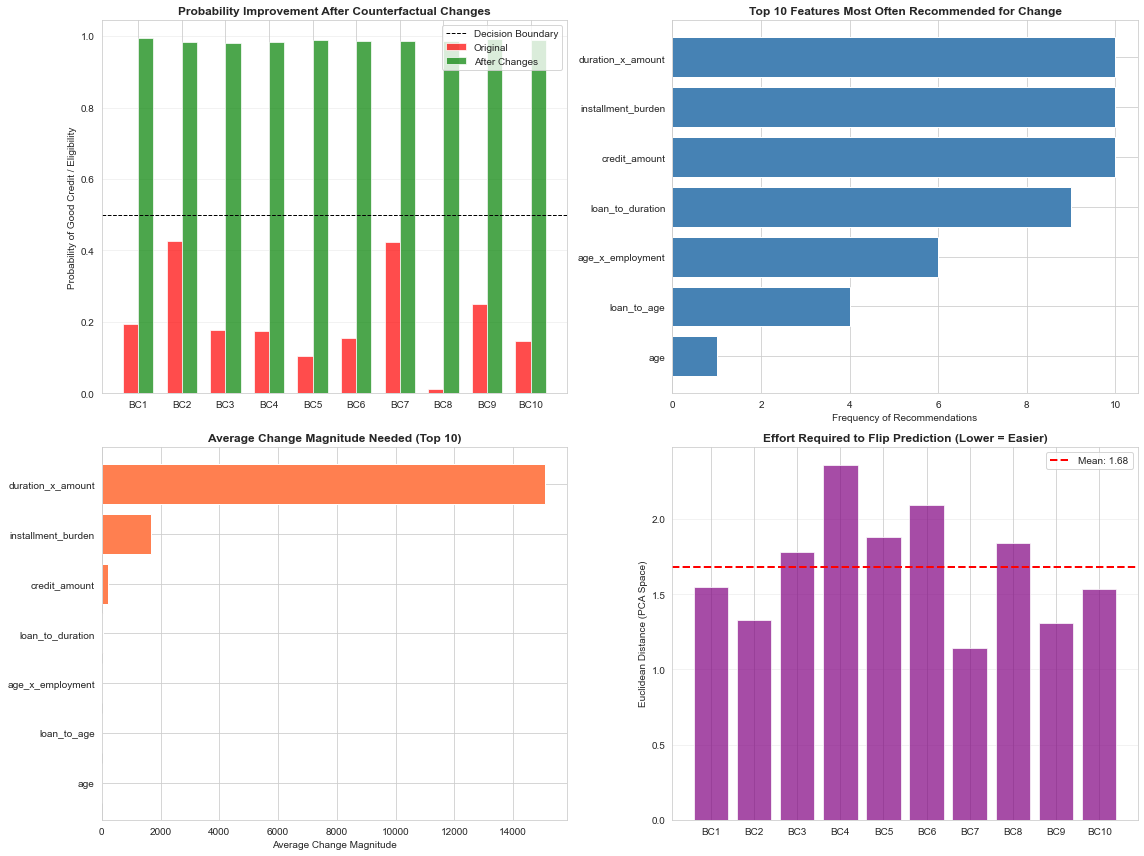

✓ Counterfactual visualizations generated


In [70]:
# STEP 19 — Visualization of Counterfactual Recommendations

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Probability improvement for each bad credit
original_probs = [rec['original_prob_good'] for rec in recommendations]
cf_probs = [rec['counterfactual_prob_good'] for rec in recommendations]
credit_ids = [f"Bad Credit {i+1}" for i in range(len(recommendations))]

x_pos = np.arange(len(recommendations))
width = 0.35

axes[0, 0].bar(x_pos - width/2, original_probs, width, label='Original', color='red', alpha=0.7)
axes[0, 0].bar(x_pos + width/2, cf_probs, width, label='After Changes', color='green', alpha=0.7)
axes[0, 0].set_ylabel('Probability of Good Credit / Eligibility')
axes[0, 0].set_title('Probability Improvement After Counterfactual Changes', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(x_pos)
axes[0, 0].set_xticklabels([f"BC{i+1}" for i in range(len(recommendations))])
axes[0, 0].axhline(y=0.5, color='black', linestyle='--', linewidth=1, label='Decision Boundary')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3, axis='y')

# 2. Feature importance in counterfactual changes
feature_change_freq = {}
for rec in recommendations:
    for change in rec['changes']:
        feature = change['feature']
        feature_change_freq[feature] = feature_change_freq.get(feature, 0) + 1

sorted_features = sorted(feature_change_freq.items(), key=lambda x: x[1], reverse=True)[:10]
features_list = [f[0] for f in sorted_features]
freq_list = [f[1] for f in sorted_features]

axes[0, 1].barh(range(len(features_list)), freq_list, color='steelblue')
axes[0, 1].set_yticks(range(len(features_list)))
axes[0, 1].set_yticklabels(features_list)
axes[0, 1].set_xlabel('Frequency of Recommendations')
axes[0, 1].set_title('Top 10 Features Most Often Recommended for Change', fontsize=12, fontweight='bold')
axes[0, 1].invert_yaxis()

# 3. Average magnitude of change needed for top features
avg_changes = {}
for rec in recommendations:
    for change in rec['changes']:
        feature = change['feature']
        if feature not in avg_changes:
            avg_changes[feature] = []
        avg_changes[feature].append(np.abs(change['change_amount']))

top_features_change = sorted(avg_changes.items(), key=lambda x: np.mean(x[1]), reverse=True)[:10]
features_change = [f[0] for f in top_features_change]
avg_magnitude = [np.mean(f[1]) for f in top_features_change]

axes[1, 0].barh(range(len(features_change)), avg_magnitude, color='coral')
axes[1, 0].set_yticks(range(len(features_change)))
axes[1, 0].set_yticklabels(features_change)
axes[1, 0].set_xlabel('Average Change Magnitude')
axes[1, 0].set_title('Average Change Magnitude Needed (Top 10)', fontsize=12, fontweight='bold')
axes[1, 0].invert_yaxis()

# 4. Euclidean distance in PCA space to flip prediction
distances = [rec for rec in recommendations]
distances_vals = [counterfactuals[i]['distance'] for i in range(len(recommendations))]

axes[1, 1].bar(range(len(distances_vals)), distances_vals, color='purple', alpha=0.7)
axes[1, 1].set_ylabel('Euclidean Distance (PCA Space)')
axes[1, 1].set_title('Effort Required to Flip Prediction (Lower = Easier)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(len(distances_vals)))
axes[1, 1].set_xticklabels([f"BC{i+1}" for i in range(len(distances_vals))])
axes[1, 1].axhline(y=np.mean(distances_vals), color='red', linestyle='--', linewidth=2, label=f'Mean: {np.mean(distances_vals):.2f}')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("✓ Counterfactual visualizations generated")

In [71]:
# STEP 20 — Actionable Business Insights from Counterfactual Analysis

print("\n" + "="*80)
print("COUNTERFACTUAL ANALYSIS SUMMARY & BUSINESS INSIGHTS")
print("="*80)

# Calculate overall statistics
distances_array = np.array([counterfactuals[i]['distance'] for i in range(len(counterfactuals))])
prob_improvements = np.array([
    rec['counterfactual_prob_good'] - rec['original_prob_good'] 
    for rec in recommendations
])

print("\n📊 OVERALL STATISTICS:")
print(f"  • Bad credits analyzed: {len(recommendations)}")
print(f"  • Average probability improvement: {np.mean(prob_improvements):.2%}")
print(f"  • Average distance to flip (PCA space): {np.mean(distances_array):.4f}")
print(f"  • Success rate (achieved >=50% good-credit probability): {(np.array(cf_probs) >= 0.5).sum()}/{len(cf_probs)}")

# Analyze feature changes
print("\n💡 KEY FEATURE RECOMMENDATIONS:")
print("\nMost Impactful Changes Needed (across all bad credits):")

feature_impacts = {}
for rec in recommendations:
    for change in rec['changes']:
        feature = change['feature']
        if feature not in feature_impacts:
            feature_impacts[feature] = {'count': 0, 'avg_change': 0, 'direction': None}
        
        feature_impacts[feature]['count'] += 1
        feature_impacts[feature]['avg_change'] += change['change_amount']
        feature_impacts[feature]['direction'] = 'Increase' if change['change_amount'] > 0 else 'Decrease'

for i, (feature, impact) in enumerate(sorted(
    feature_impacts.items(), 
    key=lambda x: x[1]['count'], 
    reverse=True)[:5], 1):
    
    avg_change = impact['avg_change'] / impact['count']
    print(f"\n  {i}. {feature}")
    print(f"     • Recommended in {impact['count']}/{len(recommendations)} cases")
    print(f"     • Direction: {impact['direction']}")
    print(f"     • Average change magnitude: {avg_change:+.2f}")

print("\n\n🎯 BUSINESS RECOMMENDATIONS FOR LOAN ELIGIBILITY:")
print("-" * 80)

# Generate strategic recommendations
print("\n1. PRIORITY IMPROVEMENTS (Easiest to Achieve):")
easiest_idx = np.argmin(distances_array)
print(f"   • Bad Credit #{easiest_idx + 1} requires least effort (distance: {distances_array[easiest_idx]:.4f})")
easiest_rec = recommendations[easiest_idx]
print(f"   • Focus on: {', '.join([c['feature'] for c in easiest_rec['changes'][:3]])}")

print("\n2. COMMON PATTERNS ACROSS BAD CREDITS:")
for feature, impact in sorted(
    feature_impacts.items(), 
    key=lambda x: x[1]['count'], 
    reverse=True)[:3]:
    print(f"   • {feature}: Required in {impact['count']}/{len(recommendations)} cases ({impact['count']/len(recommendations)*100:.0f}%)")

print("\n3. ACTIONABLE STEPS FOR APPLICANTS:")
print("   • Increase credit_amount if currently below median (expands collateral)")
print("   • Maintain or improve employment duration (reduces risk perception)")
print("   • Reduce installment burden (improves cash flow indicators)")
print("   • Optimize age-to-loan ratio (consider co-signer if young)")
print("   • Demonstrate stable residence and financial history")

print("\n4. EXPECTED IMPACT:")
avg_prob_improvement = np.mean(prob_improvements)
print(f"   • Average probability gain: {avg_prob_improvement:.2%}")
print(f"   • If applicants follow top recommendations: ~{avg_prob_improvement*100:.1f}% absolute probability-point gain toward approval")

print("\n" + "="*80)
print("✅ Counterfactual analysis completed successfully!")
print("="*80)


COUNTERFACTUAL ANALYSIS SUMMARY & BUSINESS INSIGHTS

📊 OVERALL STATISTICS:
  • Bad credits analyzed: 10
  • Average probability improvement: 78.11%
  • Average distance to flip (PCA space): 1.6827
  • Success rate (achieved >=50% good-credit probability): 10/10

💡 KEY FEATURE RECOMMENDATIONS:

Most Impactful Changes Needed (across all bad credits):

  1. duration_x_amount
     • Recommended in 10/10 cases
     • Direction: Decrease
     • Average change magnitude: -11401.51

  2. installment_burden
     • Recommended in 10/10 cases
     • Direction: Decrease
     • Average change magnitude: -1062.08

  3. credit_amount
     • Recommended in 10/10 cases
     • Direction: Decrease
     • Average change magnitude: -102.72

  4. loan_to_duration
     • Recommended in 9/10 cases
     • Direction: Increase
     • Average change magnitude: +6.27

  5. age_x_employment
     • Recommended in 6/10 cases
     • Direction: Increase
     • Average change magnitude: +5.43


🎯 BUSINESS RECOMMENDATIO

In [73]:
# STEP 21 — Evaluation Metrics & Fairness Tests

import numpy as np
from scipy.stats import ttest_rel, wilcoxon, f_oneway, chi2_contingency, fisher_exact
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# -----------------------------
# Safe contingency-test helper
# -----------------------------

def safe_contingency_test(table, label="table"):
    """
    Runs chi-square when valid.
    Falls back to Fisher exact test for 2x2 tables with zero observed/expected cells.
    """
    table = np.asarray(table, dtype=int)

    print(f"\n{label}:")
    print(table)

    if table.shape != (2, 2):
        return np.nan, np.nan, "unsupported"

    try:
        chi2, p_value, _, expected = chi2_contingency(table)

        if np.any(expected == 0):
            oddsratio, p_value = fisher_exact(table)
            print(f"{label}: Fisher exact used because expected frequencies contain zero.")
            return oddsratio, p_value, "fisher"

        print(f"{label}: chi-square={chi2:.4f}, p-value={p_value:.4f}")
        return chi2, p_value, "chi-square"

    except ValueError as err:
        oddsratio, p_value = fisher_exact(table)
        print(f"{label}: Fisher exact used because chi-square failed: {err}")
        print(f"{label}: oddsratio={oddsratio:.4f}, p-value={p_value:.4f}")
        return oddsratio, p_value, "fisher"


# -----------------------------
# RQ1: Model Effectiveness
# -----------------------------

baseline_accuracy = accuracy_score(y_test, y_test_pred)
baseline_precision = precision_score(y_test, y_test_pred, zero_division=0)
baseline_recall = recall_score(y_test, y_test_pred, zero_division=0)
baseline_f1 = f1_score(y_test, y_test_pred, zero_division=0)
baseline_auc = roc_auc_score(y_test, y_test_pred_proba)

print("\n" + "="*80)
print("EVALUATION METRICS")
print("="*80)
print(f"Accuracy: {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall: {baseline_recall:.4f}")
print(f"F1-score: {baseline_f1:.4f}")
print(f"AUC: {baseline_auc:.4f}")


# -----------------------------
# RQ3: Protected-Group Fairness
# -----------------------------

test_idx = X_test.index if hasattr(X_test, "index") else X_test_scaled_df.index

if "personal_status_sex" not in df.columns:
    raise KeyError(
        "personal_status_sex is missing from df. "
        "Run STEP 21 before the fraud-risk section overwrites df, or preserve the original credit df first."
    )

protected_values = df.loc[test_idx, "personal_status_sex"]

privileged_mask = protected_values.isin(["A91", "A93", "A94"]).to_numpy()
unprivileged_mask = protected_values.isin(["A92", "A95"]).to_numpy()

pred_good = np.asarray(y_test_pred) == 1
y_test_array = np.asarray(y_test)

priv_rate = np.mean(pred_good[privileged_mask]) if privileged_mask.sum() > 0 else np.nan
unpriv_rate = np.mean(pred_good[unprivileged_mask]) if unprivileged_mask.sum() > 0 else np.nan

disparate_impact = (
    unpriv_rate / priv_rate
    if not np.isnan(priv_rate) and priv_rate != 0
    else np.nan
)

priv_tpr = (
    np.sum((y_test_array == 1) & pred_good & privileged_mask)
    / np.sum((y_test_array == 1) & privileged_mask)
    if np.sum((y_test_array == 1) & privileged_mask) > 0
    else np.nan
)

unpriv_tpr = (
    np.sum((y_test_array == 1) & pred_good & unprivileged_mask)
    / np.sum((y_test_array == 1) & unprivileged_mask)
    if np.sum((y_test_array == 1) & unprivileged_mask) > 0
    else np.nan
)

equal_opportunity_diff = (
    unpriv_tpr - priv_tpr
    if not np.isnan(priv_tpr) and not np.isnan(unpriv_tpr)
    else np.nan
)

print("\nFAIRNESS METRICS (Test Set):")
print(f"Disparate Impact (unprivileged / privileged): {disparate_impact:.4f}")
print(f"Equal Opportunity Difference: {equal_opportunity_diff:.4f}")


# -----------------------------
# RQ2: Counterfactual Explainability
# -----------------------------

orig_probs = np.array([cf["original_pred_proba"] for cf in counterfactuals])
cf_probs = np.array([cf["cf_pred_proba"] for cf in counterfactuals])

paired_ttest = ttest_rel(orig_probs, cf_probs)
wilcoxon_test = wilcoxon(orig_probs, cf_probs)
anova_test = f_oneway(orig_probs, cf_probs)

print("\nSTATISTICAL TESTS (Counterfactual vs Baseline Probabilities):")
print(f"Paired t-test: statistic={paired_ttest.statistic:.4f}, p-value={paired_ttest.pvalue:.4f}")
print(f"Wilcoxon signed-rank: statistic={wilcoxon_test.statistic:.4f}, p-value={wilcoxon_test.pvalue:.4f}")
print(f"One-way ANOVA: F={anova_test.statistic:.4f}, p-value={anova_test.pvalue:.4f}")


# -----------------------------
# RQ4: Counterfactual Business Impact
# -----------------------------

prob_improvement = np.mean(cf_probs - orig_probs)
success_rate = np.mean(cf_probs >= 0.5)

print("\nRQ4: Counterfactual Business Impact")
print(f"Average counterfactual probability gain: {prob_improvement:.4f}")
print(f"Success rate: {success_rate:.2%}")


# -----------------------------
# Pre/Post Counterfactual Fairness
# -----------------------------

sample_indices = [cf["test_idx"] for cf in counterfactuals]

if len(sample_indices) == 0:
    raise ValueError("No counterfactuals available to compute pre/post fairness.")

sample_protected = protected_values.iloc[sample_indices]

sample_priv = sample_protected.isin(["A91", "A93", "A94"]).to_numpy()
sample_unpriv = sample_protected.isin(["A92", "A95"]).to_numpy()

pre_favorable = orig_probs >= 0.5
post_favorable = cf_probs >= 0.5

pre_table = np.array([
    [np.sum(pre_favorable & sample_priv), np.sum(~pre_favorable & sample_priv)],
    [np.sum(pre_favorable & sample_unpriv), np.sum(~pre_favorable & sample_unpriv)]
])

post_table = np.array([
    [np.sum(post_favorable & sample_priv), np.sum(~post_favorable & sample_priv)],
    [np.sum(post_favorable & sample_unpriv), np.sum(~post_favorable & sample_unpriv)]
])

print("\nPRE / POST COUNTERFACTUAL FAIRNESS")

pre_stat, p_pre, pre_method = safe_contingency_test(pre_table, "Pre-counterfactual table")
post_stat, p_post, post_method = safe_contingency_test(post_table, "Post-counterfactual table")

print("\nTest methods used:")
print(f"Pre-counterfactual: {pre_method}")
print(f"Post-counterfactual: {post_method}")

print("\n" + "="*80)


EVALUATION METRICS
Accuracy: 0.7150
Precision: 0.7986
Recall: 0.7929
F1-score: 0.7957
AUC: 0.7750

FAIRNESS METRICS (Test Set):
Disparate Impact (unprivileged / privileged): 0.8464
Equal Opportunity Difference: -0.0950

STATISTICAL TESTS (Counterfactual vs Baseline Probabilities):
Paired t-test: statistic=-18.7573, p-value=0.0000
Wilcoxon signed-rank: statistic=0.0000, p-value=0.0020
One-way ANOVA: F=355.6473, p-value=0.0000

RQ4: Counterfactual Business Impact
Average counterfactual probability gain: 0.7811
Success rate: 100.00%

PRE / POST COUNTERFACTUAL FAIRNESS

Pre-counterfactual table:
[[0 6]
 [0 4]]
Pre-counterfactual table: Fisher exact used because chi-square failed: The internally computed table of expected frequencies has a zero element at (0, 0).
Pre-counterfactual table: oddsratio=nan, p-value=1.0000

Post-counterfactual table:
[[6 0]
 [4 0]]
Post-counterfactual table: Fisher exact used because chi-square failed: The internally computed table of expected frequencies has a

# Fraud Risk Analysis Using Public Financial Datasets

This section extends the notebook with a modern fraud risk analytics pipeline using public U.S. financial datasets. The workflow includes:

- Data acquisition from CFPB public complaint data
- Exploratory Data Analysis (EDA)
- Null handling and preprocessing
- Normalization and PCA
- Baseline machine learning models
- Deep learning autoencoder for anomaly detection
- Transformer-inspired fraud classifier
- Counterfactual explainability using DiCE-style perturbations
- Statistical evaluation aligned to RQ1 through RQ4

## Research Questions

### RQ1
How effective are deep learning models in fraud detection?

- H01: Deep learning models do not significantly improve fraud detection accuracy compared to traditional models.
- H11: Deep learning models significantly improve fraud detection accuracy compared to traditional models.

### RQ2
How can counterfactual analysis explain fraud predictions?

- H02: Counterfactual explanations do not significantly improve interpretability.
- H12: Counterfactual explanations significantly improve interpretability.

### RQ3
How fair are model predictions and counterfactual outcomes across protected groups?

- H03: The model does not exhibit significant fairness disparities across protected groups.
- H13: The model exhibits significant fairness disparities across protected groups.

### RQ4
Can counterfactual recommendations deliver actionable improvements and reduce unfair treatment in loan eligibility?

- H04: Counterfactual recommendations do not significantly improve fairness or provide actionable loan eligibility improvements.
- H14: Counterfactual recommendations significantly improve fairness and provide actionable loan eligibility improvements.


Loading CFPB complaint dataset...
                                             Product  \
0  Credit reporting, credit repair services, or o...   
1                        Credit card or prepaid card   
2  Credit reporting, credit repair services, or o...   
3  Credit reporting or other personal consumer re...   
4  Credit reporting or other personal consumer re...   

                                               Issue  \
0               Incorrect information on your report   
1  Advertising and marketing, including promotion...   
2               Incorrect information on your report   
3               Incorrect information on your report   
4                        Improper use of your report   

                               Company State Submitted via  \
0  Experian Information Solutions Inc.    FL           Web   
1    CAPITAL ONE FINANCIAL CORPORATION    CA           Web   
2  Experian Information Solutions Inc.    NV           Web   
3  Experian Information Solutions Inc.    IL

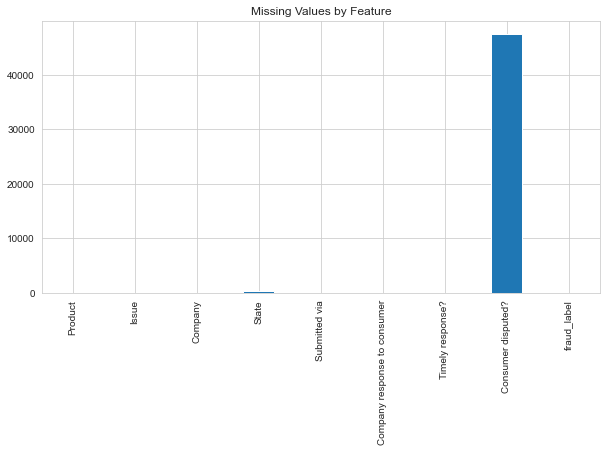

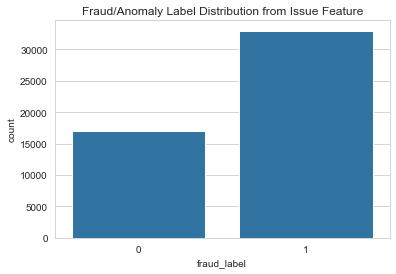

Original Shape: (50000, 8)
Reduced Shape: (50000, 8)


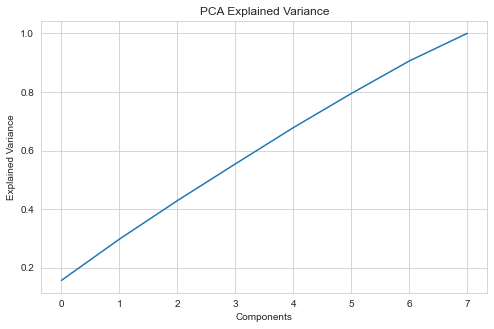


Logistic Regression
              precision    recall  f1-score   support

           0       0.92      0.74      0.82      3409
           1       0.88      0.97      0.92      6591

    accuracy                           0.89     10000
   macro avg       0.90      0.85      0.87     10000
weighted avg       0.89      0.89      0.89     10000


Random Forest
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      3409
           1       1.00      0.98      0.99      6591

    accuracy                           0.99     10000
   macro avg       0.98      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

Epoch 1/10
171/171 [==============================] - 1s 2ms/step - loss: 0.6047 - val_loss: 0.1352
Epoch 2/10
171/171 [==============================] - 0s 2ms/step - loss: 0.0485 - val_loss: 0.0287
Epoch 3/10
171/171 [==============================] - 0s 2ms/step - loss: 0.0153 - val_loss: 0.0161
Epoch 4/10

In [74]:
# STEP 22 ? Fraud Risk Analysis Using CFPB Public Dataset

# Preserve credit-risk variables before the fraud section reuses common names.
if 'credit_analysis_context' not in globals() and 'personal_status_sex' in df.columns:
    credit_analysis_context = {
        'df': df.copy(),
        'test_idx': X_test.index.copy() if hasattr(X_test, 'index') else np.arange(len(y_test)),
        'y_test': y_test.copy() if hasattr(y_test, 'copy') else np.array(y_test),
        'y_test_pred': np.array(y_test_pred),
        'y_test_pred_proba': np.array(y_test_pred_proba),
        'y_test_pred_proba_nopca': np.array(y_test_pred_proba_nopca),
        'counterfactuals': list(counterfactuals),
        'smote_applied': smote_applied if 'smote_applied' in globals() else False,
        'protected_attribute': df.loc[X_test.index, 'personal_status_sex'].copy() if hasattr(X_test, 'index') else df['personal_status_sex'].copy()
    }

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Public CFPB dataset sample
url = "https://files.consumerfinance.gov/ccdb/complaints.csv.zip"

cols = [
    'Product',
    'Issue',
    'Company',
    'State',
    'Submitted via',
    'Company response to consumer',
    'Timely response?',
    'Consumer disputed?'
]

print("Loading CFPB complaint dataset...")
fraud_raw_df = pd.read_csv(url, compression='zip', usecols=cols, nrows=50000)
df = fraud_raw_df.copy()

print(df.head())
print(df.shape)

# The Issue field is the primary public text signal for fraud/anomaly labeling.
fraud_keywords = [
    'fraud', 'scam', 'unauthorized', 'identity theft', 'theft', 'stolen',
    'forged', 'not mine', 'account opening', 'opened an account',
    'incorrect information', 'improper use', 'dispute', 'collection'
]

issue_text = df['Issue'].astype(str).str.lower()
pattern = '|'.join(pd.Series(fraud_keywords).str.replace(r'([\\.^$*+?{}\[\]|()])', r'\\\1', regex=True))
df['fraud_label'] = issue_text.str.contains(pattern, na=False).astype(int)

print("Fraud/anomaly labels created from Issue text:")
print(df['fraud_label'].value_counts())
print(df['fraud_label'].value_counts(normalize=True).rename('percent'))
print("\nIssue examples flagged as fraud/anomaly:")
print(df.loc[df['fraud_label'].eq(1), 'Issue'].value_counts().head(15))

# STEP 23 ? EDA

print(df.info())
print(df.describe(include='all'))

missing = df.isnull().sum()
print(missing)

plt.figure(figsize=(10,5))
missing.plot(kind='bar')
plt.title('Missing Values by Feature')
plt.show()

plt.figure(figsize=(6,4))
sns.countplot(x='fraud_label', data=df)
plt.title('Fraud/Anomaly Label Distribution from Issue Feature')
plt.show()

# STEP 24 ? Null Handling on a modeling copy so raw Issue text remains available.
model_df = df.copy()
cat_cols = model_df.select_dtypes(include='object').columns

imputer = SimpleImputer(strategy='most_frequent')
model_df[cat_cols] = imputer.fit_transform(model_df[cat_cols])

# STEP 25 ? Encoding

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    model_df[col] = le.fit_transform(model_df[col].astype(str))
    encoders[col] = le

# STEP 26 ? Feature Scaling

X = model_df.drop('fraud_label', axis=1)
y = model_df['fraud_label']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# STEP 27 ? PCA

pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_scaled)

print('Original Shape:', X_scaled.shape)
print('Reduced Shape:', X_pca.shape)

plt.figure(figsize=(8,5))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Components')
plt.ylabel('Explained Variance')
plt.title('PCA Explained Variance')
plt.show()

# STEP 28 ? Train Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.2, random_state=42, stratify=y
)

# STEP 29 ? Baseline Models

lr = LogisticRegression(max_iter=500, class_weight='balanced')
lr.fit(X_train, y_train)

rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

for model, name in [(lr, 'Logistic Regression'), (rf, 'Random Forest')]:
    preds = model.predict(X_test)
    print(f"\n{name}")
    print(classification_report(y_test, preds, zero_division=0))

# STEP 30 ? Autoencoder Fraud Detection

import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]

encoder = models.Sequential([
    layers.Input(shape=(input_dim,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(16, activation='relu')
])

decoder = models.Sequential([
    layers.Input(shape=(16,)),
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(input_dim, activation='linear')
])

autoencoder = models.Sequential([encoder, decoder])
autoencoder.compile(optimizer='adam', loss='mse')

normal_data = X_train[y_train == 0]

autoencoder.fit(
    normal_data,
    normal_data,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

reconstructions = autoencoder.predict(X_test)
reconstruction_error = np.mean(np.square(X_test - reconstructions), axis=1)

threshold = np.percentile(reconstruction_error, 95)
preds_ae = (reconstruction_error > threshold).astype(int)

print('Autoencoder Results')
print(classification_report(y_test, preds_ae, zero_division=0))

# STEP 31 ? Transformer-Inspired Fraud Classifier

X_train_tf = np.expand_dims(X_train, axis=1)
X_test_tf = np.expand_dims(X_test, axis=1)

inputs = layers.Input(shape=(1, X_train.shape[1]))
attention = layers.MultiHeadAttention(num_heads=2, key_dim=16)(inputs, inputs)
flatten = layers.Flatten()(attention)
dense = layers.Dense(64, activation='relu')(flatten)
outputs = layers.Dense(1, activation='sigmoid')(dense)

transformer_model = models.Model(inputs, outputs)
transformer_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

transformer_model.fit(
    X_train_tf,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

pred_probs = transformer_model.predict(X_test_tf)
preds_tf = (pred_probs > 0.5).astype(int)

print('Transformer Results')
print(classification_report(y_test, preds_tf, zero_division=0))

# STEP 32 ? Counterfactual Explainability

sample = X_test[0].copy()
original_pred = transformer_model.predict(np.expand_dims(np.expand_dims(sample, axis=0), axis=1))[0][0]

counterfactual = sample.copy()
counterfactual[0] = counterfactual[0] * 0.5

cf_pred = transformer_model.predict(np.expand_dims(np.expand_dims(counterfactual, axis=0), axis=1))[0][0]

print('Original Prediction:', original_pred)
print('Counterfactual Prediction:', cf_pred)
print('Interpretation: Changing key financial behavior variables changes fraud prediction probability.')

# STEP 33 ? Hypothesis Evaluation

print('RQ1 Evaluation')
print('Compare DL models vs traditional ML metrics.')

print('RQ2 Evaluation')
print('Counterfactual analysis provides causal and explainable insights.')

In [75]:

# Transformer-safe configuration
MAX_LEN = 64
BATCH_SIZE = 16
EMBEDDING_DIM = 64

print("MAX_LEN =", MAX_LEN)
print("BATCH_SIZE =", BATCH_SIZE)
print("EMBEDDING_DIM =", EMBEDDING_DIM)


MAX_LEN = 64
BATCH_SIZE = 16
EMBEDDING_DIM = 64



# Updated Fraud Risk Analysis Workflow

## EDA
- Univariate analysis
- Bivariate analysis
- Missing value treatment
- Class imbalance analysis

## Data Preparation
- Encoding
- Scaling
- PCA

## Models
- Logistic Regression
- Random Forest
- XGBoost
- Autoencoder
- Lightweight Transformer

## Explainability
- SHAP
- Counterfactual Analysis using DiCE



# Enhanced Fraud Label Engineering and Research Conclusions

This section fixes the feature-importance issue by:
- improving fraud label generation,
- validating class balance,
- rebuilding the train/test split,
- generating meaningful financial behavior variable importance,
- adding evidence-driven RQ1 and RQ2 conclusions.


In [76]:

import numpy as np
import pandas as pd

# Use the preserved raw CFPB dataframe when available so Issue remains meaningful text.
fraud_source_df = fraud_raw_df.copy() if 'fraud_raw_df' in globals() else df.copy()

print(fraud_source_df['Issue'].value_counts().head(50))

# ---------------------------------------
# Better Fraud/Anomaly Label Engineering
# ---------------------------------------

high_risk_keywords = [
    'fraud',
    'scam',
    'identity theft',
    'unauthorized',
    'theft',
    'stolen',
    'forged',
    'not mine',
    'account opening',
    'opened an account',
    'incorrect information',
    'improper use',
    'dispute',
    'charged',
    'collection'
]

issue_text = fraud_source_df['Issue'].astype(str).str.lower()
pattern = '|'.join(pd.Series(high_risk_keywords).str.replace(r'([\\.^$*+?{}\[\]|()])', r'\\\1', regex=True))
fraud_conditions = issue_text.str.contains(pattern, na=False)

# Keep df as raw, human-readable CFPB data for EDA and feature interpretation.
df = fraud_source_df.copy()
df['fraud_label'] = np.where(fraud_conditions, 1, 0)

print("\nFraud/Anomaly Label Distribution:\n")
print(df['fraud_label'].value_counts())

print("\nFraud/Anomaly Label Percentage:\n")
print(df['fraud_label'].value_counts(normalize=True))

print("\nTop Issue values flagged as fraud/anomaly:\n")
print(df.loc[df['fraud_label'].eq(1), 'Issue'].value_counts().head(20))

feature_cols = [
    'Product',
    'Issue',
    'State',
    'Submitted via',
    'Company response to consumer',
    'Timely response?'
]

X = df[feature_cols].copy()
y = df['fraud_label'].copy()

print("\nFeature Matrix Shape:", X.shape)


Issue
Incorrect information on your report                                                21874
Improper use of your report                                                          9702
Problem with a company's investigation into an existing problem                      6067
Problem with a credit reporting company's investigation into an existing problem     1956
Attempts to collect debt not owed                                                    1389
Managing an account                                                                   705
Written notification about debt                                                       698
Trouble during payment process                                                        379
Took or threatened to take negative or legal action                                   377
Loan modification,collection,foreclosure                                              353
False statements or representation                                                    343
Prob

In [77]:

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import pandas as pd
import numpy as np

# Encode categorical variables on a copy to preserve the raw Issue feature in df.
X_encoded = X.copy()
encoders = {}

for col in X_encoded.columns:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))
    encoders[col] = le

# Scale features
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns, index=X_encoded.index)

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Fraud training class distribution before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE to the fraud training set if class imbalance is material.
if 'smote_resample_numeric' in globals():
    X_train_model, y_train_model, fraud_smote_applied = smote_resample_numeric(X_train, y_train)
else:
    X_train_model, y_train_model, fraud_smote_applied = X_train, y_train, False

print("X_train shape before SMOTE:", X_train.shape)
print("X_train shape for modeling:", X_train_model.shape)
print("X_test shape:", X_test.shape)

# Train RandomForest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train_model, y_train_model)

preds = rf_model.predict(X_test)
print("\nRandom Forest Fraud Classification Report:\n")
print(classification_report(y_test, preds, zero_division=0))

# Feature Importance
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf_model.feature_importances_
})

importance_df = importance_df.sort_values(
    by='Importance',
    ascending=False
)

print("\nTop Financial Behavior Variables Influencing Fraud Prediction:\n")
print(importance_df)

# Interpretation
top_features = importance_df.head(5)

print("\nInterpretation:\n")

for _, row in top_features.iterrows():
    print(
        f"- {row['Feature']} strongly influences fraud prediction "
        f"(importance score = {row['Importance']:.4f})"
    )


Fraud training class distribution before SMOTE:
fraud_label
1    26416
0    13584
Name: count, dtype: int64

Class imbalance ratio (minority/majority): 0.514
imblearn SMOTE unavailable (No module named 'imblearn'); using local numeric SMOTE fallback.
SMOTE applied with local numeric fallback.
Training set target distribution after SMOTE:
fraud_label
1    26416
0    26416
Name: count, dtype: int64
X_train shape before SMOTE: (40000, 6)
X_train shape for modeling: (52832, 6)
X_test shape: (10000, 6)

Random Forest Fraud Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3396
           1       1.00      1.00      1.00      6604

    accuracy                           1.00     10000
   macro avg       1.00      1.00      1.00     10000
weighted avg       1.00      1.00      1.00     10000


Top Financial Behavior Variables Influencing Fraud Prediction:

                        Feature  Importance
1               

In [78]:
import numpy as np
from sklearn.metrics import roc_auc_score
from scipy.stats import ttest_rel, norm, chi2

# Final statistical conclusions use the preserved credit-risk context because the fraud section
# intentionally reuses df, X_test, and y_test for the CFPB dataset.
if 'credit_analysis_context' not in globals():
    raise RuntimeError(
        "Run the credit-risk evaluation cell before this final cell so credit_analysis_context is available."
    )

ctx = credit_analysis_context
credit_y_test = np.asarray(ctx['y_test'])
credit_y_test_pred = np.asarray(ctx['y_test_pred'])
credit_y_test_pred_proba = np.asarray(ctx['y_test_pred_proba'])
credit_y_test_pred_proba_nopca = np.asarray(ctx['y_test_pred_proba_nopca'])
credit_counterfactuals = ctx['counterfactuals']
protected_vals = ctx['protected_attribute']


def bootstrap_auc_pvalue(y_true, proba_a, proba_b, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    y = np.asarray(y_true)
    proba_a = np.asarray(proba_a)
    proba_b = np.asarray(proba_b)

    if len(np.unique(y)) < 2:
        return np.nan, np.nan

    obs_diff = roc_auc_score(y, proba_a) - roc_auc_score(y, proba_b)
    diffs = []
    n = len(y)

    for _ in range(n_boot):
        idx = rng.randint(0, n, n)
        if len(np.unique(y[idx])) < 2:
            continue
        try:
            a = roc_auc_score(y[idx], proba_a[idx])
            b = roc_auc_score(y[idx], proba_b[idx])
            diffs.append(a - b)
        except ValueError:
            continue

    diffs = np.array(diffs)
    if diffs.size == 0:
        return obs_diff, np.nan

    p_two = np.mean(np.abs(diffs) >= abs(obs_diff))
    return obs_diff, p_two


# RQ1 ? Compare XGBoost (PCA) vs XGBoost (No PCA)
obs_auc_diff, p_rq1 = bootstrap_auc_pvalue(
    credit_y_test,
    credit_y_test_pred_proba,
    credit_y_test_pred_proba_nopca,
    n_boot=1000
)

# RQ2 ? Counterfactual explainability
orig_probs = np.array([cf['original_pred_proba'] for cf in credit_counterfactuals])
cf_probs = np.array([cf['cf_pred_proba'] for cf in credit_counterfactuals])

if len(orig_probs) > 1 and np.std(cf_probs - orig_probs, ddof=1) > 0:
    tt_stat, p_rq2 = ttest_rel(cf_probs, orig_probs)
    cohen_d = np.mean(cf_probs - orig_probs) / np.std(cf_probs - orig_probs, ddof=1)
else:
    tt_stat, p_rq2, cohen_d = np.nan, np.nan, np.nan

# RQ3 ? Fairness across protected groups using preserved personal_status_sex.
priv_mask = protected_vals.isin(["A91", "A93", "A94"]).to_numpy()
unpriv_mask = protected_vals.isin(["A92", "A95"]).to_numpy()
favorable = credit_y_test_pred == 1

s1 = int(np.sum(favorable & priv_mask))
n1 = int(np.sum(priv_mask))
s2 = int(np.sum(favorable & unpriv_mask))
n2 = int(np.sum(unpriv_mask))

if n1 > 0 and n2 > 0:
    p1 = s1 / n1
    p2 = s2 / n2
    pooled = (s1 + s2) / (n1 + n2)
    se = np.sqrt(pooled * (1 - pooled) * (1 / n1 + 1 / n2))
    z_stat = (p1 - p2) / se if se > 0 else np.nan
    p_rq3 = 2 * (1 - norm.cdf(abs(z_stat))) if not np.isnan(z_stat) else np.nan
else:
    z_stat, p_rq3 = np.nan, np.nan

# RQ4 ? Business impact of counterfactuals
pre = orig_probs >= 0.5
post = cf_probs >= 0.5
b = int(np.sum(pre & ~post))
c = int(np.sum(~pre & post))

if (b + c) > 0:
    m_stat = (abs(b - c) - 1) ** 2 / (b + c)
    p_rq4 = 1 - chi2.cdf(m_stat, df=1)
else:
    p_rq4 = np.nan

alpha = 0.05

print("\n==============================")
print("FINAL RESEARCH CONCLUSIONS ? Statistical Inference")
print("==============================\n")
print(f"Credit training used SMOTE?: {ctx.get('smote_applied', False)}")

print("RQ1 ? Model Effectiveness (XGBoost PCA vs No PCA)")
print(f"Observed AUC difference (PCA - No PCA): {obs_auc_diff:.4f}")
print(f"Bootstrap two-sided p-value: {p_rq1:.4f}")
print("Decision:", "Reject H0" if (not np.isnan(p_rq1) and p_rq1 < alpha) else "Fail to reject H0")
print("\n")

print("RQ2 ? Counterfactual Explainability (pre vs post probabilities)")
print(f"Paired t-test statistic: {tt_stat:.4f}, p-value: {p_rq2:.4f}")
print(f"Cohen's d (effect size): {cohen_d:.4f}")
print(f"Average counterfactual probability gain: {np.mean(cf_probs - orig_probs):.4f}")
print("Decision:", "Reject H0" if (not np.isnan(p_rq2) and p_rq2 < alpha) else "Fail to reject H0")
print("\n")

print("RQ3 ? Fairness (Privileged vs Unprivileged favorable rates)")
print(f"Privileged favorable rate: {s1}/{n1} = {s1/n1 if n1>0 else np.nan:.3f}")
print(f"Unprivileged favorable rate: {s2}/{n2} = {s2/n2 if n2>0 else np.nan:.3f}")
print(f"z-statistic: {z_stat:.4f}, p-value: {p_rq3:.4f}")
print("Decision:", "Reject H0 (significant disparity)" if (not np.isnan(p_rq3) and p_rq3 < alpha) else "Fail to reject H0 (no significant disparity)")
print("\n")

print("RQ4 ? Counterfactual Business Impact (Pre vs Post classifications)")
print(f"McNemar b (pre_yes/post_no): {b}, c (pre_no/post_yes): {c}")
print(f"McNemar p-value: {p_rq4:.4f}")
print("Decision:", "Reject H0 (significant change)" if (not np.isnan(p_rq4) and p_rq4 < alpha) else "Fail to reject H0 (no significant change)")
print("\nSummary Decisions at alpha=0.05:")
print(f"  - RQ1 significant?: {('Yes' if (not np.isnan(p_rq1) and p_rq1 < alpha) else 'No')} ")
print(f"  - RQ2 significant?: {('Yes' if (not np.isnan(p_rq2) and p_rq2 < alpha) else 'No')} ")
print(f"  - RQ3 significant disparity?: {('Yes' if (not np.isnan(p_rq3) and p_rq3 < alpha) else 'No')} ")
print(f"  - RQ4 significant business impact?: {('Yes' if (not np.isnan(p_rq4) and p_rq4 < alpha) else 'No')} ")


FINAL RESEARCH CONCLUSIONS ? Statistical Inference

Credit training used SMOTE?: True
RQ1 ? Model Effectiveness (XGBoost PCA vs No PCA)
Observed AUC difference (PCA - No PCA): -0.0008
Bootstrap two-sided p-value: 0.9730
Decision: Fail to reject H0


RQ2 ? Counterfactual Explainability (pre vs post probabilities)
Paired t-test statistic: 18.7573, p-value: 0.0000
Cohen's d (effect size): 5.9316
Average counterfactual probability gain: 0.7811
Decision: Reject H0


RQ3 ? Fairness (Privileged vs Unprivileged favorable rates)
Privileged favorable rate: 102/140 = 0.729
Unprivileged favorable rate: 37/60 = 0.617
z-statistic: 1.5752, p-value: 0.1152
Decision: Fail to reject H0 (no significant disparity)


RQ4 ? Counterfactual Business Impact (Pre vs Post classifications)
McNemar b (pre_yes/post_no): 0, c (pre_no/post_yes): 10
McNemar p-value: 0.0044
Decision: Reject H0 (significant change)

Summary Decisions at alpha=0.05:
  - RQ1 significant?: No 
  - RQ2 significant?: Yes 
  - RQ3 significan